# Simulating Intertemporal Choice

This notebook uses the hyperbolic delay-discounting model from Notebook 1
to simulate choices between smaller-sooner and larger-later rewards.

For each choice, the delayed reward is converted into its subjective value:

V = A / (1 + kD)

The simulated participant chooses whichever option has the greater
subjective value. For now, this is deterministic.

In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

np.random.seed(42)

In [3]:
def subjective_value(amount, delay, k):
    value = amount / (1 + k * delay)
    return value

In [4]:
#Decision 1

k = 0.01

immediate_value = subjective_value(40, 0, k)
delayed_value = subjective_value(70, 90, k)

print(immediate_value, delayed_value)

40.0 36.8421052631579


In [5]:
def choose_reward(immediate_amount, delayed_amount, delay, k):
    immediate_value = subjective_value(immediate_amount, 0, k)
    delayed_value = subjective_value(delayed_amount, delay, k)
    if immediate_value < delayed_value:
        return "Delayed"
    elif immediate_value > delayed_value:
        return "Immediate"
    else:
        return "Either"

In [6]:
k_values = [0.001, 0.01, 0.05, 0.1]

for k in k_values:
    choice = choose_reward(40, 70, 90, k)
    print(k, choice)

0.001 Delayed
0.01 Immediate
0.05 Immediate
0.1 Immediate


In [7]:
choices = [
    {"immediate": 20, "delayed": 25, "delay": 7},
    {"immediate": 40, "delayed": 70, "delay": 90},
    {"immediate": 50, "delayed": 100, "delay": 365},
    {"immediate": 30, "delayed": 50, "delay": 30},
    {"immediate": 45, "delayed": 60, "delay": 180}
]

results = []
d = {}

for k in k_values:
    for choice in choices:
       d = {
        "k": k,
        "immediate_amount": choice["immediate"],
        "delayed_amount": choice["delayed"],
        "delay": choice["delay"],
        "choice": choose_reward(choice["immediate"], choice["delayed"], choice["delay"], k)
       }
       results.append(d)

df = pd.DataFrame(results)

df

,k,immediate_amount,delayed_amount,delay,choice
0,0.001,20,25,7,Delayed
1,0.001,40,70,90,Delayed
2,0.001,50,100,365,Delayed
3,0.001,30,50,30,Delayed
4,0.001,45,60,180,Delayed
5,0.010,20,25,7,Delayed
6,0.010,40,70,90,Immediate
7,0.010,50,100,365,Immediate
8,0.010,30,50,30,Delayed
9,0.010,45,60,180,Immediate


In [8]:
df["is_immediate"] = (df["choice"] == "Immediate").astype(int)

immediate_rates = df.groupby("k")["is_immediate"].mean() * 100

immediate_rates

k
0.001      0.0
0.010     60.0
0.050    100.0
0.100    100.0
Name: is_immediate, dtype: float64

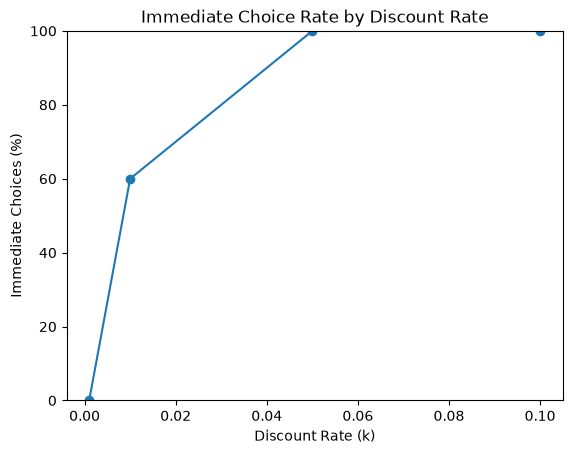

In [12]:
plt.plot(immediate_rates.index, immediate_rates.values, marker="o")

plt.xlabel("Discount Rate (k)")
plt.ylabel("Immediate Choices (%)")
plt.title("Immediate Choice Rate by Discount Rate")
plt.ylim(0, 100)

plt.show()

Interpretation: As the discount rate k increases, the simulated participant chooses the immediate reward more frequently. Higher k values cause delayed rewards to lose subjective value more rapidly, producing a stronger preference for smaller-sooner rewards. Because this simulation uses only five deterministic choices per k, the resulting percentages change in large discrete steps.

In [16]:
def delayed_choice_probability(immediate_amount, delayed_amount, delay, k, beta):
    immediate_value = subjective_value(immediate_amount, 0, k)
    delayed_value = subjective_value(delayed_amount, delay, k)
    value_difference = delayed_value - immediate_value

    probability_delayed = 1 / (1 + np.exp(-beta * value_difference))

    return probability_delayed

In [17]:
immediate_amount = 40
delayed_amount = 70
delay = 90
k = 0.01
beta = 1

p_delayed = delayed_choice_probability(
    immediate_amount,
    delayed_amount,
    delay,
    k,
    beta
)

print(p_delayed)

0.04078132812927288


In [20]:
def choose_reward_probabilistic(
    immediate_amount,
    delayed_amount,
    delay,
    k,
    beta
):
    p_delayed = delayed_choice_probability(
        immediate_amount,
        delayed_amount,
        delay,
        k,
        beta
    )

    random_draw = np.random.random()

    if random_draw < p_delayed:
        return "Delayed"
    else:
        return "Immediate"

In [21]:
for i in range(10):
    print(
        choose_reward_probabilistic(
            40,
            70,
            90,
            0.01,
            1
        )
    )

Immediate
Immediate
Immediate
Immediate
Immediate
Immediate
Immediate
Immediate
Immediate
Immediate


In [23]:
num_trials = 1000

delayed_count = 0
immediate_count = 0

for i in range(num_trials):
    choice = choose_reward_probabilistic(
        40,
        70,
        90,
        0.01,
        1
    )

    # increment the appropriate count
    if choice == "Delayed":
        delayed_count += 1
    else:
        immediate_count += 1

observed_delayed_percent = delayed_count / num_trials * 100

print(observed_delayed_percent)

4.3


Simulation check: For $40 now vs. $70 in 90 days with k = 0.01 and β = 1, the model predicted a delayed-choice probability of about 4.08%. Across 1,000 simulated trials, the observed delayed-choice rate was 4.3%, closely matching the theoretical probability.

In [26]:
beta_values = [0.1, 0.5, 1, 2, 5]

for beta in beta_values:
    p_delayed = delayed_choice_probability(
        40,
        70,
        90,
        0.01,
        beta
    )
    
    print(beta, p_delayed)

0.1 0.4217022267039683
0.5 0.17094461198713226
1 0.04078132812927288
2 0.0018042768939281286
5 1.389052455284165e-07


In [ ]:
beta_values = [0.1, 0.5, 1, 2, 5]
probabilities = []

for beta in beta_values:
    p_delayed = delayed_choice_probability(
        40,
        70,
        90,
        0.01,
        beta
    )

    probabilities.append(p_delayed)

In [ ]:
plt.plot(beta_values, probabilities, marker="o")

plt.xlabel("Choice Sensitivity (β)")
plt.ylabel("Probability of Delayed Choice")
plt.title("Effect of Choice Sensitivity on Decision Probability")

plt.ylim(0, 0.5)

plt.show()